In [ ]:
import sys
sys.path.insert(0, "..") 
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
import os
import src.kz as kz
DOF   = kz.DOF      # lattice sites (1024)
N_WIN = 11
FONTSIZE = 16



Following the original paper, we build a simple recurrent neural network to model the one dimensional snapshots. 
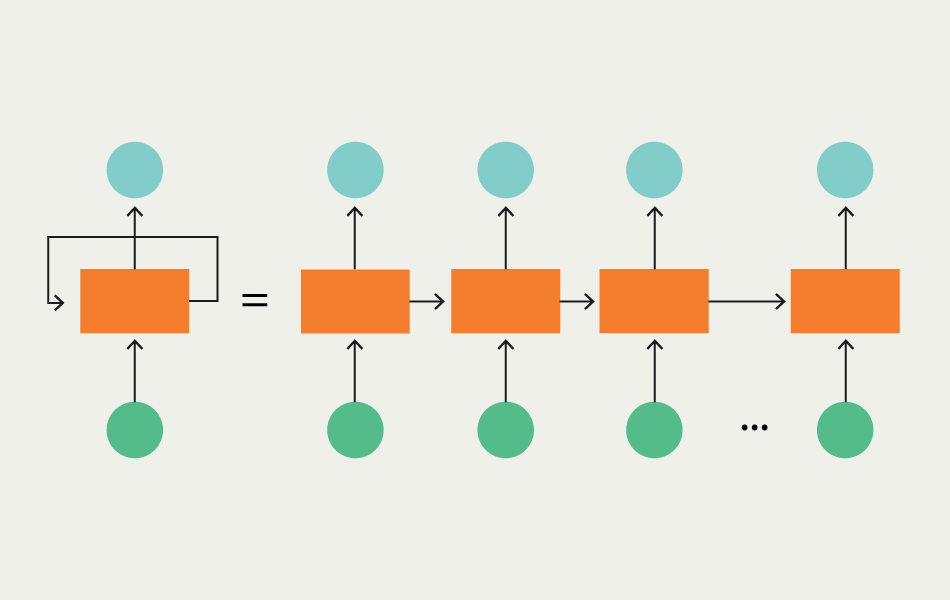

A recurrent nueral network approximates real-time processes as a series of snapshots, the idea being the model should learn to infer the dynamics of time evolution. 


By using five snapshots of the field configuration in the freezeout regime, the model is able to learn the momentum of the field.

Let's design our simple model

In [4]:

def build_model():
    """SimpleRNN over the time window -> final field at every site (as in the original paper)."""
    model = keras.Sequential([
        keras.layers.Input(shape=(N_WIN, DOF)),
        keras.layers.SimpleRNN(256, activation="softsign"),
        keras.layers.Dense(DOF),
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

KZ_model = build_model()
KZ_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       263,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,104 (2.25 MB)

 Trainable params: 591,104 (2.25 MB)

 Non-trainable params: 0 (0.00 B)

Now we need data on which to train the model. Using a simple numerical integrator, we generate thousands of field trajectories over the quench.

We have data generated for this repository, but you can choose your own values of $\tau$ by running `python -m scripts/kz1d/generate_data.py <TAU>` (This may take a while!)

With the data generated, we load it into the notebook and choose our preferred sample time

In [6]:
d = kz.load(128, outdir='../data')
T_SAMPLE = 50

Now we'll prep our tensors for training.

In [7]:

X = kz.window(d, T_SAMPLE).astype('float32')     # (N, 11, 1024)
Y = d['phi_final'].astype('float32')            # (N, 1024)
print(X.shape, Y.shape)
#Useful for normalization
print('input  scale:', np.abs(X).std()) 
print('target scale:', np.abs(Y).std())

(3000, 11, 1024) (3000, 1024)
input  scale: 0.008369446
target scale: 0.16179712


In [ ]:
# ---- inputs ----
T_LIST   = [0, 20, 50, 70]   # times to show
SAMPLE   = -1                # which sample (any index; -1 = last, a validation sample)

ts = d["ts"]
x  = kz.grid()
colors = plt.cm.viridis(np.linspace(0, 0.9, len(T_LIST)))

plt.figure(figsize=(12, 5))
for t, c in zip(T_LIST, colors):
    j = int(np.argmin(np.abs(ts - t)))          # nearest stored snapshot
    plt.plot(x, d["phi_hist"][SAMPLE, j], color=c, lw=1.2, label=rf"$t = {ts[j]:.0f}$")
plt.plot(x, d["phi_final"][SAMPLE], "k-", lw=2, label=rf"final, $t = \tau = {TAU}$")

plt.axhline(0, color="grey", lw=0.8)
plt.xlim(0, kz.L())
plt.xlabel(r"$x$", fontsize=FONTSIZE)
plt.ylabel(r"$\phi$", fontsize=FONTSIZE)
plt.title("Field growth during the quench (one sample)", fontsize=FONTSIZE)
plt.tick_params(labelsize=FONTSIZE - 2)
plt.legend(fontsize=FONTSIZE - 2, loc="upper right")
plt.tight_layout()
plt.show()

Now let's train our model

In [8]:
hist = KZ_model.fit(X, Y, epochs=60, batch_size=10, validation_split=0.2)

Epoch 1/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.5776 - val_loss: 0.4277
Epoch 2/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3628 - val_loss: 0.3241
Epoch 3/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2918 - val_loss: 0.2777
Epoch 4/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2501 - val_loss: 0.2421
Epoch 5/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2195 - val_loss: 0.2139
Epoch 6/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1952 - val_loss: 0.2044
Epoch 7/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1749 - val_loss: 0.1746
Epoch 8/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1573 - val_loss: 0.1589
Epoch 9/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1438 - val_loss: 0.1513
Epoch 10/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1342 - val_loss: 0.1482
Epoch 11/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1220 - val_loss: 0.1315
Epoch 12/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

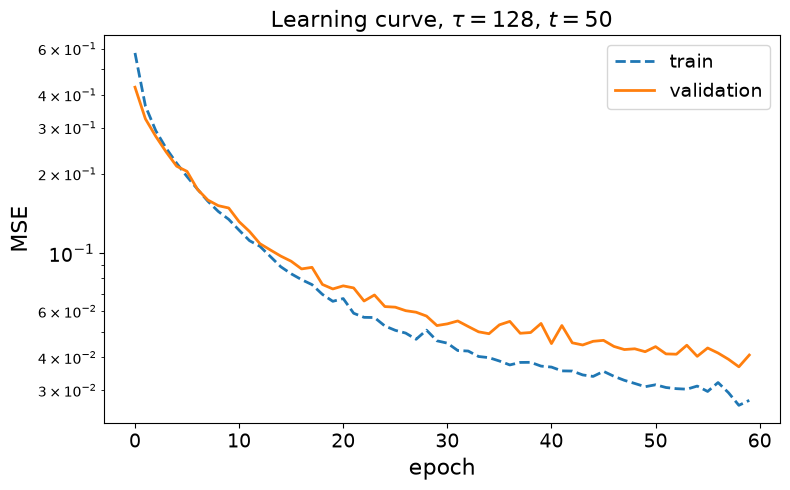

In [10]:
FONTSIZE = 16

plt.figure(figsize=(8, 5))
plt.plot(hist.history["loss"],     "--", lw=2, label="train")
plt.plot(hist.history["val_loss"], "-",  lw=2, label="validation")
plt.xlabel("epoch", fontsize=FONTSIZE)
plt.ylabel("MSE", fontsize=FONTSIZE)
plt.yscale("log")
plt.title(rf"Learning curve, $\tau = {int(kz.TAU)}$, $t = {T_SAMPLE}$", fontsize=FONTSIZE)
plt.tick_params(labelsize=FONTSIZE - 2)
plt.legend(fontsize=FONTSIZE - 2)
plt.tight_layout()
plt.show()

As we can see, the model trains well, and that training extend to the validation data it has not seen.

Let's visualize now what our model actually learned:

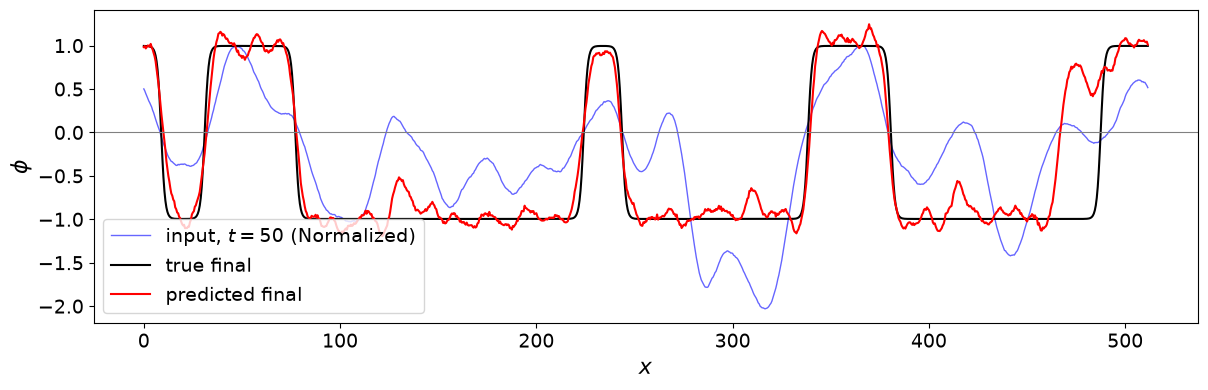

In [29]:
N_VAL  = int(0.2 * len(X))   # Keras validation_split holds out the last 20%
SAMPLE = 8                  # which validation sample to plot
MID    = N_WIN // 2          # middle snapshot of the input window (index 5, time t = T_SAMPLE)
X_val, Y_val = X[-N_VAL:], Y[-N_VAL:]
Y_pred = KZ_model.predict(X_val, verbose=0)

plt.figure(figsize=(12, 4))
plt.plot(kz.grid(), X_val[SAMPLE, MID]/np.abs(X_val[SAMPLE, MID].max()), "b-", lw=1.0, alpha=0.6, label=rf"input, $t = {T_SAMPLE}$ (Normalized)")
plt.plot(kz.grid(), Y_val[SAMPLE],      "k-", lw=1.5, label="true final")
plt.plot(kz.grid(), Y_pred[SAMPLE],     "r-", lw=1.5, label="predicted final")
plt.axhline(0, color="grey", lw=0.8)
plt.xlabel(r"$x$", fontsize=FONTSIZE)
plt.ylabel(r"$\phi$", fontsize=FONTSIZE)
plt.tick_params(labelsize=FONTSIZE - 2)
plt.legend(fontsize=FONTSIZE - 2)
plt.tight_layout()
plt.show()

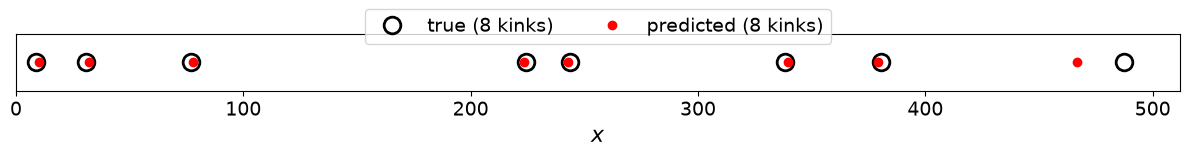

In [31]:

# kink positions: where phi crosses zero (interpolated), true vs predicted
x_true = kz.defect_positions(Y_val[SAMPLE].astype(np.float64))
x_pred = kz.defect_positions(Y_pred[SAMPLE].astype(np.float64))

plt.figure(figsize=(12, 2.5))
plt.plot(x_true, np.zeros(len(x_true)), "o", mfc="none", mec="k", ms=12, mew=2,
         label=f"true ({len(x_true)} kinks)")
plt.plot(x_pred, np.zeros(len(x_pred)), "o", color="r", ms=6,
         label=f"predicted ({len(x_pred)} kinks)")
plt.xlim(0, kz.L())
plt.yticks([])
plt.xlabel(r"$x$", fontsize=FONTSIZE)
plt.tick_params(labelsize=FONTSIZE - 2)
plt.legend(fontsize=FONTSIZE - 2, loc="upper center", bbox_to_anchor=(0.5, 1.6), ncol=2)
plt.tight_layout()
plt.show()

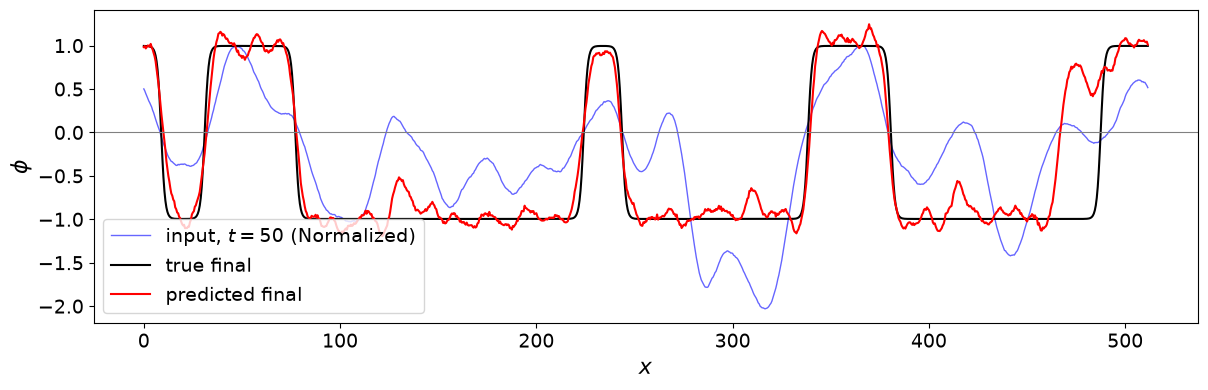
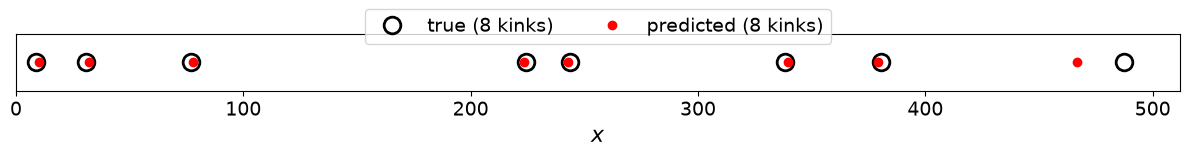

As we can see, the model is able to learn not only the number of the Kibble-zurek domains, but the locations of them as well.

Now consider the same run, but evaluated at different times.


In [23]:
for T_SAMPLE in [-80, 20, 50, 70]:
    X = g.window(d, T_SAMPLE).astype('float32')
    Y = d['phi_final'].astype('float32')
    model = keras.Sequential([
        keras.layers.Input(shape=(11, 1024)),
        keras.layers.SimpleRNN(256, activation='softsign'),
        keras.layers.Dense(1024)
    ])
    model.compile(optimizer='adam', loss='mse')
    h = model.fit(X, Y, epochs=60, batch_size=10, validation_split=0.2, verbose=0)
    print(T_SAMPLE, h.history['val_loss'][-1])

-80 1.0547558069229126
20 0.28348028659820557
50 0.04032529890537262
70 0.02343696355819702


In [25]:
def lowpass(X, kc):
    F = np.fft.rfft(X, axis=-1)
    k = 2*np.pi*np.fft.rfftfreq(X.shape[-1], d=kz.dx)
    F[..., k > kc] = 0
    return np.fft.irfft(F, n=X.shape[-1], axis=-1)


T_SAMPLE = 50
X = g.window(d, T_SAMPLE).astype('float32')
Y = d['phi_final'].astype('float32')

k_hat = 1.0/(np.sqrt(2)*(kz.TAU/(2*kz.eta))**0.25)     # 1/xi_hat
KCS   = k_hat*np.array([0.25, 0.5, 1, 2, 4, 8, 1e6])

val = []
for kc in KCS:
    Xf = lowpass(X, kc).astype('float32')
    model = keras.Sequential([
        keras.layers.Input(shape=(11, 1024)),
        keras.layers.SimpleRNN(256, activation='softsign'),
        keras.layers.Dense(1024)
    ])
    model.compile(optimizer='adam', loss='mse')
    h = model.fit(Xf, Y, epochs=60, batch_size=10, validation_split=0.2, verbose=0)
    val.append(h.history['val_loss'][-1])
    print(f'kc/k_hat={kc/k_hat:8.2f}  val={val[-1]:.4f}')

val = np.array(val)

kc/k_hat=    0.25  val=0.5640
kc/k_hat=    0.50  val=0.1760
kc/k_hat=    1.00  val=0.0408
kc/k_hat=    2.00  val=0.0437
kc/k_hat=    4.00  val=0.0399
kc/k_hat=    8.00  val=0.0399
kc/k_hat=1000000.00  val=0.0457


In [28]:
T_SAMPLE = 50
X = g.window(d, T_SAMPLE).astype('float32')
Y = d['phi_final'].astype('float32')
x = kz.grid()

k_hat = 1.0/(np.sqrt(2)*(kz.TAU/(2*kz.eta))**0.25)
Xf = lowpass(X, k_hat).astype('float32')

def train(Xin):
    m = keras.Sequential([keras.layers.Input(shape=(11, 1024)),
                          keras.layers.SimpleRNN(256, activation='softsign'),
                          keras.layers.Dense(1024)])
    m.compile(optimizer='adam', loss='mse')
    m.fit(Xin, Y, epochs=60, batch_size=10, validation_split=0.2, verbose=0)
    return m

m_full = train(X)
m_filt = train(Xf)

n_val = int(0.2*len(X))
P_full = m_full.predict(X[-n_val:],  verbose=0)
P_filt = m_filt.predict(Xf[-n_val:], verbose=0)

j       = 0                      # which validation sample to show
y_true  = Y[-n_val:][j]
in_full = X[-n_val:][j, 5]       # middle snapshot of the window
in_filt = Xf[-n_val:][j, 5]
p_full  = P_full[j]
p_filt  = P_filt[j]

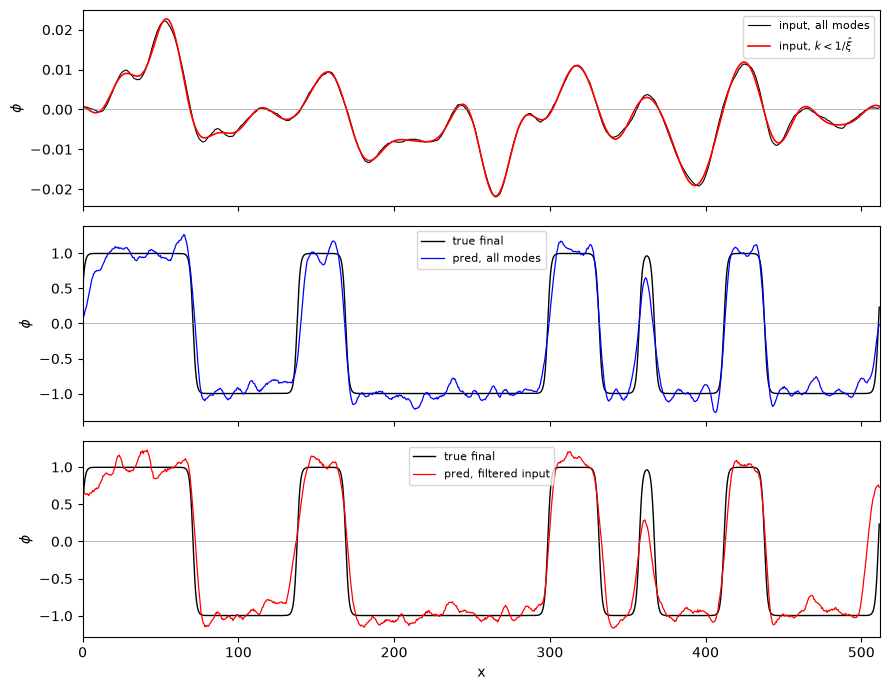

In [29]:
fig, ax = plt.subplots(3, 1, figsize=(9, 7), sharex=True)

ax[0].plot(x, in_full, 'k-', lw=0.8, label='input, all modes')
ax[0].plot(x, in_filt, 'r-', lw=1.2, label=r'input, $k<1/\hat\xi$')
ax[0].legend(fontsize=8); ax[0].set_ylabel(r'$\phi$')

ax[1].plot(x, y_true, 'k-', lw=1.0, label='true final')
ax[1].plot(x, p_full, 'b-', lw=0.9, label='pred, all modes')
ax[1].legend(fontsize=8); ax[1].set_ylabel(r'$\phi$')

ax[2].plot(x, y_true, 'k-', lw=1.0, label='true final')
ax[2].plot(x, p_filt, 'r-', lw=0.9, label='pred, filtered input')
ax[2].legend(fontsize=8); ax[2].set_ylabel(r'$\phi$'); ax[2].set_xlabel('x')

for a in ax:
    a.axhline(0, color='grey', lw=0.4)
    a.set_xlim(0, kz.L())
plt.tight_layout()

In [30]:
print('MSE  full:', ((P_full - Y[-n_val:])**2).mean())
print('MSE  filt:', ((P_filt - Y[-n_val:])**2).mean())

nt = kz.count_defects(Y[-n_val:].astype(np.float64))
nf = kz.count_defects(P_full.astype(np.float64))
ng = kz.count_defects(P_filt.astype(np.float64))
print('count accuracy  full:', (nf == nt).mean())
print('count accuracy  filt:', (ng == nt).mean())

MSE  full: 0.040165506
MSE  filt: 0.03818305
count accuracy  full: 0.78
count accuracy  filt: 0.8066666666666666


In [32]:
print(np.bincount(nf - nt + 6))     # offset to keep indices positive

[  0   0  11   0  84   0 468   0  36   0   1]
